In [ ]:
import pandas as pd
import numpy as np

In [126]:
# Step 1: Load the data
df = pd.read_csv('train.csv', header=None)

In [127]:
# Step 2: Drop columns with high percentage of missing values
missing_percentages = df.isnull().sum() / len(df) * 100
high_missing_cols = missing_percentages[missing_percentages > 50].index
df = df.drop(columns=high_missing_cols)

Which columns with a missing value percentage greater than 50%, we dropped from the DataFrame using the drop() method.

In [128]:
# Step 3: Fill missing values in numeric columns with mean
numeric_cols = df.select_dtypes(include=['int', 'float']).columns
low_missing_cols = missing_percentages[missing_percentages <= 50].index.intersection(numeric_cols)
for col in low_missing_cols:
    col_mean = df[col].mean()
    df[col].fillna(col_mean, inplace=True)

Using mean()to calculate the average of numerical columns' values and filling the missing values with the corresponding averages.

In [129]:
# Step 4: Fill missing values in non-numeric columns with mode
non_numeric_cols = df.select_dtypes(exclude=['int', 'float']).columns
for col in non_numeric_cols:
    col_mode = df[col].mode()[0]
    df[col].fillna(col_mode, inplace=True)

Using the select_dtypes() method with the exclude parameter, we filled the non-numeric data in df with frequently.

In [139]:
df.isnull().sum().sum() #check for any missing

0

In [132]:
# Step 5: Convert the last column into a binary label column
binary_label = pd.Series(np.where(df.iloc[:, -1].values == 'one', 1, 0), name='binary_label', index=df.index)
df.drop(columns=df.columns[-1], inplace=True)
df = pd.concat([df, binary_label], axis=1)


<ipython-input-132-8beae0b1f33b>:2: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  binary_label = pd.Series(np.where(df.iloc[:, -1].values == 'one', 1, 0), name='binary_label', index=df.index)


we created a binary tag column with integer values (1 and 0), a common format for machine-learning tasks

In [133]:
# Check for missing values in the DataFrame and binary label column
print("Total number of missing values in DataFrame:", df.isnull().sum().sum())
print("Total number of missing values in binary label column:", binary_label.isnull().sum())
print(f"Non-numerical columns number is: {len(non_numeric_cols)}")
print(f"Numerical columns number is: {len(numeric_cols)}")
print(f"Total number of rows in the DataFrame: {len(df)}")
print(f"Total number of columns in the DataFrame: {len(df.columns)}")

Total number of missing values in DataFrame: 0
Total number of missing values in binary label column: 0
Non-numerical columns number is: 13
Numerical columns number is: 68
Total number of rows in the DataFrame: 246008
Total number of columns in the DataFrame: 81


In [134]:
# Compute pairwise correlation of columns
corr_matrix = df.corr()

# Print the correlation matrix
print(corr_matrix)

#The table shows the pairwise correlation matrix between each column of the DataFrame. 

<ipython-input-134-99c9db16e700>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


                     0         1         8         9        12        13  \
0             1.000000  0.002158  0.000674  0.000783 -0.004177  0.001684   
1             0.002158  1.000000 -0.024953  0.034254 -0.032462 -0.063060   
8             0.000674 -0.024953  1.000000 -0.033737  0.010511  0.052609   
9             0.000783  0.034254 -0.033737  1.000000 -0.062209 -0.112429   
12           -0.004177 -0.032462  0.010511 -0.062209  1.000000  0.052491   
...                ...       ...       ...       ...       ...       ...   
116          -0.003278 -0.001019 -0.000117 -0.000126 -0.000631  0.004453   
118          -0.001356  0.016947 -0.009139  0.015101 -0.001837 -0.023432   
119           0.001583 -0.011141  0.023627 -0.185541  0.037443  0.081270   
120          -0.000061 -0.121515  0.078427 -0.087137  0.018026  0.081089   
binary_label       NaN       NaN       NaN       NaN       NaN       NaN   

                    15        19        20        23  ...       108       109  \
0     

some visualizations about the data

Binary_label is already non-numerical, so it is NaN value for here.

<ipython-input-136-12e915063a21>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


<Axes: >

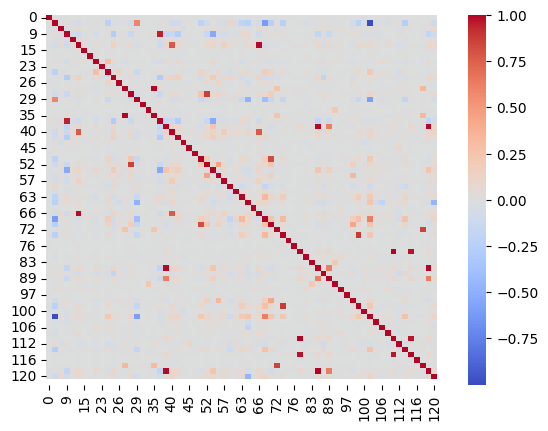

In [136]:
import seaborn as sns

# Compute correlation matrix
corr = df.corr()

# Generate heatmap
sns.heatmap(corr, cmap='coolwarm')

This corelation information can be useful in feature selection, identifying multicollinearity, and understanding the relationships between variables in the dataset.

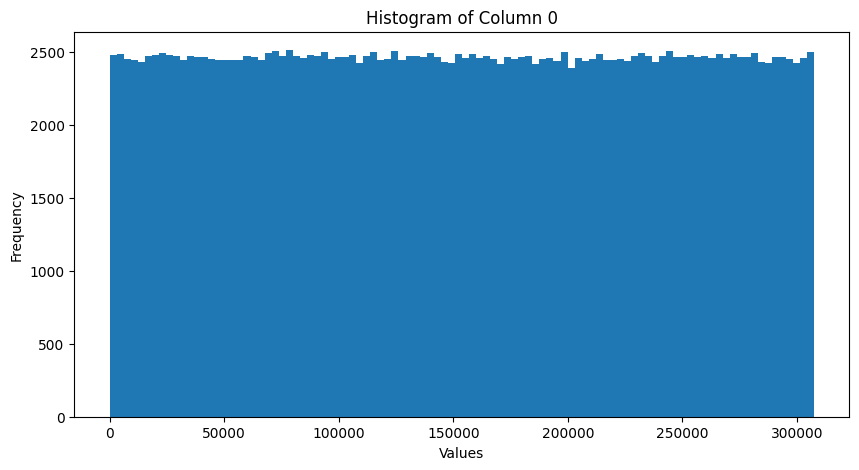

In [137]:
import matplotlib.pyplot as plt

# Select the first numerical column
num_col = df.iloc[:, 0]

# Plot a histogram
plt.figure(figsize=(10,5))
plt.hist(num_col, bins=100)
plt.title('Histogram of Column 0')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()







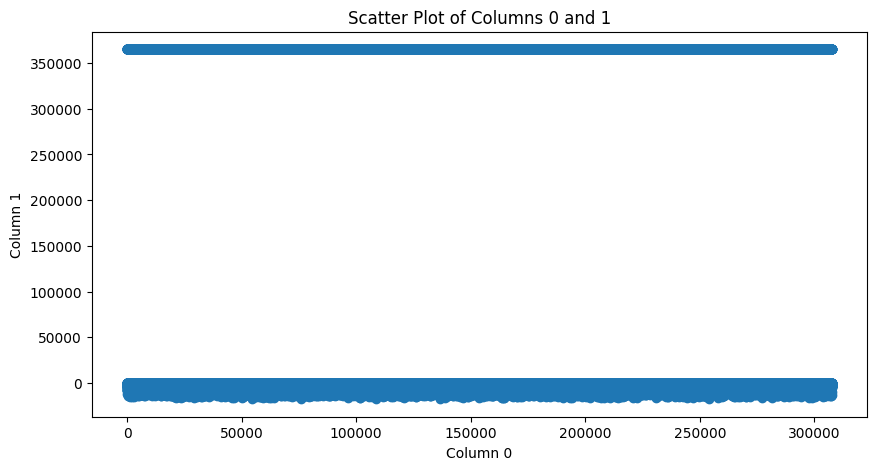

In [138]:
num_col1 = df.iloc[:, 0]
num_col2 = df.iloc[:, 1]

# Plot a scatter plot
plt.figure(figsize=(10,5))
plt.scatter(num_col1, num_col2)
plt.title('Scatter Plot of Columns 0 and 1')
plt.xlabel('Column 0')
plt.ylabel('Column 1')
plt.show()